# 01 Build CSV from Raw IWR Sample

- 分別掃描 `IWR_steady/raw/mmWave` 與 `IWR_unsteady/raw/mmWave`
- 逐筆讀取每個 sample 資料夾中的 `replay_*.json`
- 合併並排序 replay frames
- 從 `vitals.heartWaveform` 抽出時間序列
- 回到 `IWR_steady/`、`IWR_unsteady/` 底下，為每筆建立對應資料夾
- 把波形存成 `waveform.csv`

In [61]:
from __future__ import annotations

import json, re
from pathlib import Path
from collections import Counter
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from collections import Counter
from typing import Any, Dict, List, Optional
import pandas as pd

# ===== demo input =====
ROOTS = {
    "IWR_steady": Path("D:/mmwave-heart-rate-monitoring-demo/data/IWR_steady/raw/mmWave"),
    "IWR_unsteady": Path("D:/mmwave-heart-rate-monitoring-demo/data/IWR_unsteady/raw/mmWave"),
}

OUT_ROOTS = {
    "IWR_steady": Path("D:/mmwave-heart-rate-monitoring-demo/data/IWR_steady"),
    "IWR_unsteady": Path("D:/mmwave-heart-rate-monitoring-demo/data/IWR_unsteady"),
}

if __name__ == "__main__":
    for label, root in ROOTS.items():
        print(f"\n[{label}] {root}")
        if root.exists():
            folders = sorted([p for p in root.iterdir() if p.is_dir() and not p.name.startswith(".")])
            print("Total sample folders:", len(folders))
            for f in folders[:3]:
                print(" -", f.name)
        else:
            print("Directory not found")


[IWR_steady] D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\raw\mmWave
Total sample folders: 0

[IWR_unsteady] D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\raw\mmWave
Total sample folders: 60
 - sample_0
 - sample_1
 - sample_10


In [68]:
def _load_json(path: Path) -> Any:
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except UnicodeDecodeError:
        return json.loads(path.read_text(encoding="utf-8-sig"))

def _extract_frames(obj: Any) -> List[dict]:
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    if isinstance(obj, dict):
        if isinstance(obj.get("data"), list):
            return [x for x in obj["data"] if isinstance(x, dict)]
        if any(k in obj for k in ("timestamp", "Timestamp", "frameData")):
            return [obj]
    return []

def _get_ts_ms(fr: dict) -> Optional[float]:
    ts = fr.get("timestamp", None)
    if ts is None:
        ts = fr.get("Timestamp", None)
    if ts is None:
        return None
    try:
        return float(ts)
    except Exception:
        return None

def _replay_index(p: Path) -> Tuple[int, str]:
    m = re.search(r"replay_(\d+)$", p.stem)
    if m:
        return (int(m.group(1)), p.stem)
    return (10**9, p.stem)

def merge_replays(folder: Path) -> Tuple[List[dict], List[Path]]:
    replay_paths = sorted(folder.glob("replay_*.json"), key=_replay_index)

    merged: List[dict] = []
    for p in replay_paths:
        try:
            J = _load_json(p)
            merged.extend(_extract_frames(J))
        except Exception as e:
            print(f"[WARN] 讀取失敗: {p} ({e})")

    merged = [fr for fr in merged if _get_ts_ms(fr) is not None]
    merged.sort(key=lambda fr: _get_ts_ms(fr) or 0.0)

    dedup: List[dict] = []
    seen = set()
    for fr in merged:
        fd = fr.get("frameData") or {}
        fn = fd.get("frameNum", None)
        ts = _get_ts_ms(fr) or 0.0
        key = (fn, int(round(ts)))  # ms 級去重
        if key not in seen:
            seen.add(key)
            dedup.append(fr)

    return dedup, replay_paths


if __name__ == "__main__":
    # demo：拿第一個 unsteady sample 測試
    sample_folder = sorted([p for p in ROOTS["IWR_unsteady"].iterdir() if p.is_dir()])[10]
    frames, replay_paths = merge_replays(sample_folder)

    print("Sample folder :", sample_folder.name)
    print("Replay files  :", len(replay_paths))
    for p in replay_paths:
        print(" -", p.name)
    print("Merged frames :", len(frames))
    print("First frame keys:", list(frames[0].keys())[:10] if frames else [])

Sample folder : sample_18
Replay files  : 7
 - replay_1.json
 - replay_2.json
 - replay_3.json
 - replay_4.json
 - replay_5.json
 - replay_6.json
 - replay_7.json
Merged frames : 700
First frame keys: ['frameData', 'timestamp']


In [63]:
def preview_vitals_packets(frames: List[dict]):
    packets = []
    for fr in frames:
        fd = fr.get("frameData") or {}
        vit = fd.get("vitals")
        if not vit:
            continue
        hw = vit.get("heartWaveform", None)
        if hw is None:
            continue
        ts = _get_ts_ms(fr)
        if ts is None:
            continue

        packets.append({
            "ts_ms": float(ts),
            "frameNum": fd.get("frameNum", None),
            "rangeBin": vit.get("rangeBin", None),
            "heartRate": vit.get("heartRate", None),
            "heartWaveform": hw,
        })
    return packets

if __name__ == "__main__":

    packets = preview_vitals_packets(frames)

    print("Packets with vitals:", len(packets))
    if packets:
        print("First packet:")
        print({
            "ts_ms": packets[0]["ts_ms"],
            "frameNum": packets[0]["frameNum"],
            "rangeBin": packets[0]["rangeBin"],
            "heartRate": packets[0]["heartRate"],
            "heartWaveform_len": len(packets[0]["heartWaveform"]) if isinstance(packets[0]["heartWaveform"], list) else None
        })

        lengths = [len(p["heartWaveform"]) for p in packets if isinstance(p["heartWaveform"], list)]
        print("Most common waveform length:", Counter(lengths).most_common(5))

Packets with vitals: 43
First packet:
{'ts_ms': 1772114989784.5906, 'frameNum': 16, 'rangeBin': 8, 'heartRate': 50.222999572753906, 'heartWaveform_len': 15}
Most common waveform length: [(15, 43)]


Series meta:
{'packets_used': 43, 'samples_per_packet': 15, 'fs': 10.41873778789182, 'duration_s': 61.81551236979167, 'rangeBin_mode': 11, 'heartRate_median': 61.94169998168945}
time_s shape: (645,)
lsb shape   : (645,)


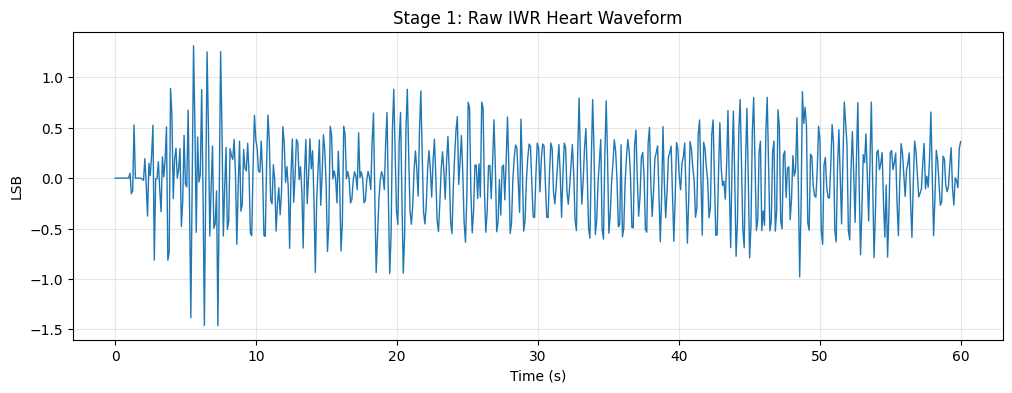

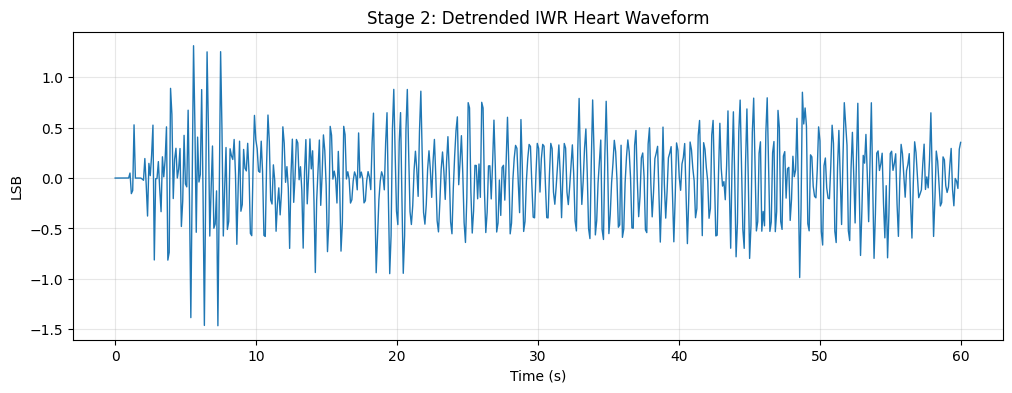

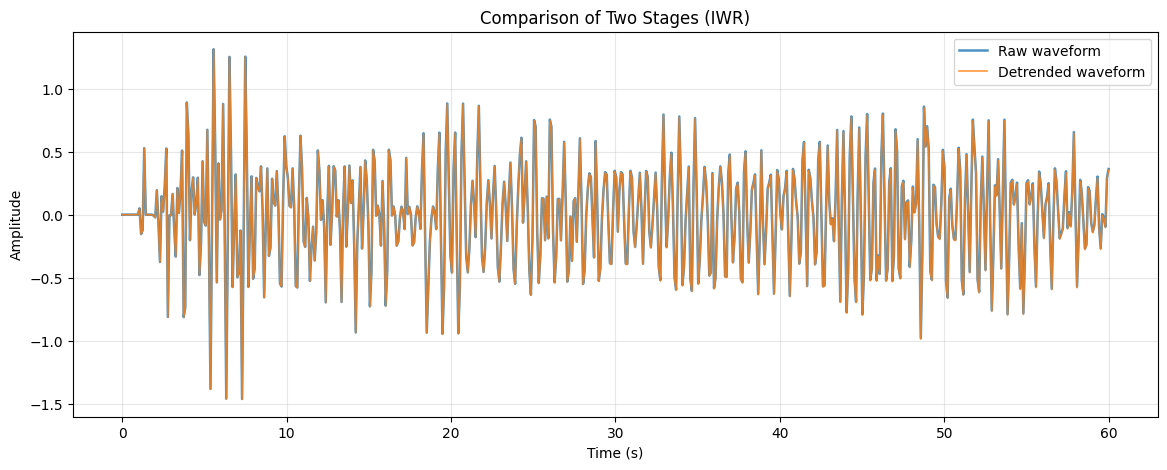

In [64]:
def _normalize_to_unit(x: np.ndarray) -> np.ndarray:
    if x.size == 0:
        return x
    m = np.nanmax(np.abs(x))
    if not np.isfinite(m) or m == 0:
        return x
    return x / m


def _build_time_axis(packet_times_s: List[float], spp: int, fallback_dt: float = 0.2) -> np.ndarray:
    n = len(packet_times_s)
    if n == 0:
        return np.array([], dtype=float)

    dts: List[Optional[float]] = []
    for i in range(n - 1):
        t0, t1 = packet_times_s[i], packet_times_s[i + 1]
        if (t1 is None) or (t0 is None) or (t1 <= t0):
            dts.append(None)
        else:
            dts.append((t1 - t0) / float(spp))

    valid = [dt for dt in dts if dt is not None and dt > 0]
    fb = float(np.median(valid)) if valid else float(fallback_dt)

    total = n * spp
    times = np.empty(total, dtype=float)
    write = 0
    for i in range(n):
        t0 = packet_times_s[i]
        dt = dts[i] if (i < n - 1 and dts[i] is not None and dts[i] > 0) else fb
        local = t0 + dt * np.arange(spp, dtype=float)
        times[write: write + spp] = local
        write += spp
    return times


def vitals_to_series(frames: List[dict], normalize: bool = False) -> Dict[str, Any]:
    packets = []
    for fr in frames:
        fd = fr.get("frameData") or {}
        vit = fd.get("vitals")
        if not vit:
            continue

        hw = vit.get("heartWaveform", None)
        if hw is None:
            continue

        ts = _get_ts_ms(fr)
        if ts is None:
            continue

        packets.append(
            {
                "ts_ms": float(ts),
                "frameNum": fd.get("frameNum", None),
                "rangeBin": vit.get("rangeBin", None),
                "heartRate": vit.get("heartRate", None),
                "heartWaveform": hw,
            }
        )

    packets.sort(key=lambda x: x["ts_ms"])

    if not packets:
        return {
            "time_s": np.array([], dtype=float),
            "lsb": np.array([], dtype=float),
            "meta": {"packets_used": 0, "samples_per_packet": 0},
        }

    lens = [len(p["heartWaveform"]) for p in packets if isinstance(p.get("heartWaveform"), list)]
    spp = Counter(lens).most_common(1)[0][0] if lens else 15

    t0_ms = packets[0]["ts_ms"]
    packet_times_s = [(p["ts_ms"] - t0_ms) / 1000.0 for p in packets]
    times = _build_time_axis(packet_times_s, spp, fallback_dt=0.2)

    vals: List[float] = []
    for p in packets:
        hw = p.get("heartWaveform")
        hw_list = hw if isinstance(hw, list) else []

        tmp = []
        for v in hw_list:
            try:
                tmp.append(float(v))
            except Exception:
                tmp.append(float("nan"))

        if len(tmp) >= spp:
            tmp = tmp[:spp]
        else:
            tmp = tmp + [float("nan")] * (spp - len(tmp))

        vals.extend(tmp)

    lsb = np.asarray(vals, dtype=float)

    if normalize:
        lsb = _normalize_to_unit(lsb)

    rb_vals = [p["rangeBin"] for p in packets if p.get("rangeBin") is not None]
    rb_mode = Counter(rb_vals).most_common(1)[0][0] if rb_vals else None

    hr_vals = [p["heartRate"] for p in packets if p.get("heartRate") is not None]
    hr_med = float(np.median(hr_vals)) if hr_vals else float("nan")

    if times.size >= 2:
        dt_med = float(np.median(np.diff(times)))
        fs = (1.0 / dt_med) if dt_med > 0 else float("nan")
    else:
        fs = float("nan")

    meta = {
        "packets_used": len(packets),
        "samples_per_packet": spp,
        "fs": fs,
        "duration_s": float(times[-1] - times[0]) if times.size else 0.0,
        "rangeBin_mode": rb_mode,
        "heartRate_median": hr_med,
    }

    return {"time_s": times, "lsb": lsb, "meta": meta}


def waveform_raw(lsb: np.ndarray) -> np.ndarray:
    x = np.asarray(lsb, dtype=float).copy()
    return x


def waveform_detrended(lsb: np.ndarray) -> np.ndarray:
    x = np.asarray(lsb, dtype=float).copy()

    finite_mask = np.isfinite(x)
    if np.sum(finite_mask) < 2:
        return x

    # 用線性插值補 NaN，避免 detrend / filter 出錯
    idx = np.arange(x.size)
    x_interp = x.copy()
    x_interp[~finite_mask] = np.interp(idx[~finite_mask], idx[finite_mask], x[finite_mask])

    x_detrend = signal.detrend(x_interp, type="linear")
    return x_detrend


if __name__ == "__main__":
    # frames 需要前面已經存在，例如：
    # frames, replay_paths = merge_replays(sample_folder)

    series = vitals_to_series(frames, normalize=False)

    time_s = series["time_s"]
    lsb = series["lsb"]
    meta = series["meta"]
    fs = meta["fs"]

    print("Series meta:")
    print(meta)
    print("time_s shape:", time_s.shape)
    print("lsb shape   :", lsb.shape)

    raw_wave = waveform_raw(lsb)
    detrended_wave = waveform_detrended(lsb)
    bandpassed_wave, fmin, fmax_eff = waveform_bandpassed(lsb, fs, fmin=0.8, fmax=3.0, normalize=True)

    # demo 範圍：前 20 秒
    mask = time_s <= 60

    # Stage 1: Raw
    plt.figure(figsize=(12, 4))
    plt.plot(time_s[mask], raw_wave[mask], linewidth=1)
    plt.title("Stage 1: Raw IWR Heart Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("LSB")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Stage 2: Detrended
    plt.figure(figsize=(12, 4))
    plt.plot(time_s[mask], detrended_wave[mask], linewidth=1)
    plt.title("Stage 2: Detrended IWR Heart Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("LSB")
    plt.grid(True, alpha=0.3)
    plt.show()


    # 二階段同圖比較
    plt.figure(figsize=(14, 5))
    plt.plot(time_s[mask], raw_wave[mask], linewidth=1.8, alpha=0.8, label="Raw waveform")
    plt.plot(time_s[mask], detrended_wave[mask], linewidth=1.2, alpha=0.8, label="Detrended waveform") # 把訊號中「慢慢往上或往下漂移的基線（baseline drift）」拿掉，只留下真正的振動訊號。
    plt.title("Comparison of Two Stages (IWR)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [65]:
from pathlib import Path
from typing import Any, Dict, Optional, List
from collections import Counter
import numpy as np


def write_data_csv(out_csv: Path, time_s: np.ndarray, lsb: np.ndarray, meta: Dict[str, Any]) -> None:
    out_csv.parent.mkdir(parents=True, exist_ok=True)

    with out_csv.open("w", encoding="utf-8", newline="\n") as f:
        for k, v in meta.items():
            f.write(f"# {k}={v}\n")
        f.write("time,LSB\n")

        n = min(time_s.size, lsb.size)
        for i in range(n):
            t = float(time_s[i])
            v = float(lsb[i])
            if not np.isfinite(v) or not np.isfinite(t):
                continue
            f.write(f"{t:.12f},{v:.9f}\n")


def batch_convert_condition_samplename(
    in_root: str | Path,
    out_root: str | Path,
    normalize: bool = True,
    overwrite: bool = True,
    limit: Optional[int] = None,
):
    in_root = Path(in_root)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    folders = sorted([p for p in in_root.iterdir() if p.is_dir() and not p.name.startswith(".")])
    if not folders:
        print(f"[WARN] 沒有子資料夾: {in_root}")
        return

    if limit is not None:
        folders = folders[:limit]

    for folder in folders:
        frames, replay_paths = merge_replays(folder)
        if not replay_paths:
            print(f"[SKIP] {folder.name}: no replay files")
            continue

        series = vitals_to_series(frames, normalize=normalize)

        # 改成：建立同名資料夾，再存 waveform.csv
        sample_dir = out_root / folder.name
        out_csv = sample_dir / "waveform.csv"

        if out_csv.exists() and (not overwrite):
            print(f"[SKIP] {out_csv} 已存在")
            continue

        meta = {
            "source_folder": folder.name,
            "source_path": str(folder),
            "replays_used": len(replay_paths),
            **series["meta"],
        }

        write_data_csv(out_csv, series["time_s"], series["lsb"], meta)
        print(f"[OK] {folder.name} -> {out_csv}")

    print(f"[DONE] {in_root} -> {out_root}")


if __name__ == "__main__":
    batch_convert_condition_samplename(
        in_root=ROOTS["IWR_unsteady"],
        out_root=OUT_ROOTS["IWR_unsteady"],
        normalize=True,
        overwrite=True,
        # limit=1,   # demo 先跑前 1 筆
    )

[OK] sample_0 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_0\waveform.csv
[OK] sample_1 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_1\waveform.csv
[OK] sample_10 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_10\waveform.csv
[OK] sample_11 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_11\waveform.csv
[OK] sample_12 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_12\waveform.csv
[OK] sample_13 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_13\waveform.csv
[OK] sample_14 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_14\waveform.csv
[OK] sample_15 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_15\waveform.csv
[OK] sample_16 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_16\waveform.csv
[OK] sample_17 -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_unsteady\sample_17\waveform.csv
[OK] sample_18 -> D:\mmwave-heart-rate-monit

In [70]:
def batch_convert_iwr_sample_csv(
    in_root: str | Path,
    out_root: str | Path,
    normalize: bool = False,
    overwrite: bool = True,
    limit: Optional[int] = None,
):
    in_root = Path(in_root)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    csv_files = sorted([p for p in in_root.rglob("*.csv") if p.is_file()])
    if not csv_files:
        print(f"[WARN] 找不到任何 csv: {in_root}")
        return

    if limit is not None:
        csv_files = csv_files[:limit]

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {csv_path.name}: read csv failed -> {e}")
            continue

        required_cols = {"Frame_Number", "Timestamp", "Heart_Waveform"}
        if not required_cols.issubset(df.columns):
            print(f"[SKIP] {csv_path.name}: 缺少欄位 {required_cols - set(df.columns)}")
            continue

        # 保留原始順序，避免 groupby 排序打亂
        grouped = []
        for frame_id, g in df.groupby("Frame_Number", sort=False):
            ts_vals = pd.to_numeric(g["Timestamp"], errors="coerce").to_numpy(dtype=float)
            wf_vals = pd.to_numeric(g["Heart_Waveform"], errors="coerce").to_numpy(dtype=float)

            ts_vals = ts_vals[np.isfinite(ts_vals)]
            if ts_vals.size == 0:
                continue

            ts_frame = float(ts_vals[0])  # 同一 frame 內 timestamp 應相同
            grouped.append({
                "frame": frame_id,
                "timestamp_ms": ts_frame,
                "waveform": wf_vals,
                "n": len(wf_vals),
            })

        if len(grouped) == 0:
            print(f"[SKIP] {csv_path.name}: 無有效 frame")
            continue

        frame_ts_ms = np.array([x["timestamp_ms"] for x in grouped], dtype=float)

        # 若是 epoch ms，轉成秒
        if np.nanmedian(frame_ts_ms) > 1e10:
            frame_ts_s = frame_ts_ms / 1000.0
        else:
            frame_ts_s = frame_ts_ms.copy()

        # 轉成相對時間
        frame_ts_s = frame_ts_s - frame_ts_s[0]

        # 計算 frame 間隔
        frame_dt = np.diff(frame_ts_s)
        valid_dt = frame_dt[np.isfinite(frame_dt) & (frame_dt > 0)]
        fallback_dt = float(np.median(valid_dt)) if valid_dt.size > 0 else 0.1

        time_list = []
        wave_list = []

        # 將每個 frame 內的 waveform 點均勻攤到對應時間區間
        for i, item in enumerate(grouped):
            wf = item["waveform"]
            n = len(wf)
            if n == 0:
                continue

            t0 = frame_ts_s[i]
            if i < len(grouped) - 1:
                t1 = frame_ts_s[i + 1]
                if not np.isfinite(t1) or t1 <= t0:
                    t1 = t0 + fallback_dt
            else:
                t1 = t0 + fallback_dt

            # n 個樣本平均分佈在 [t0, t1) 區間
            seg_t = np.linspace(t0, t1, n, endpoint=False, dtype=float)

            time_list.append(seg_t)
            wave_list.append(wf.astype(float))

        if len(time_list) == 0 or len(wave_list) == 0:
            print(f"[SKIP] {csv_path.name}: 無有效 waveform")
            continue

        time_s = np.concatenate(time_list)
        lsb = np.concatenate(wave_list)

        finite_mask = np.isfinite(time_s) & np.isfinite(lsb)
        time_s = time_s[finite_mask]
        lsb = lsb[finite_mask]

        if time_s.size == 0 or lsb.size == 0:
            print(f"[SKIP] {csv_path.name}: 全部資料無效")
            continue

        if normalize:
            lsb = _normalize_to_unit(lsb)

        # 估計 fs
        dt2 = np.diff(time_s)
        valid_dt2 = dt2[np.isfinite(dt2) & (dt2 > 0)]
        fs = (1.0 / float(np.median(valid_dt2))) if valid_dt2.size > 0 else float("nan")

        hr_vals = None
        if "Heart_Rate" in df.columns:
            hr_vals = pd.to_numeric(df["Heart_Rate"], errors="coerce").to_numpy(dtype=float)
            hr_vals = hr_vals[np.isfinite(hr_vals)]

        sample_name = csv_path.stem
        sample_dir = out_root / sample_name
        out_csv = sample_dir / "waveform.csv"

        if out_csv.exists() and (not overwrite):
            print(f"[SKIP] {out_csv} 已存在")
            continue

        meta = {
            "source_file": csv_path.name,
            "source_path": str(csv_path),
            "rows_raw": int(len(df)),
            "frames": int(len(grouped)),
            "rows_used": int(len(lsb)),
            "fs": fs,
            "duration_s": float(time_s[-1] - time_s[0]) if len(time_s) >= 2 else 0.0,
            "frame_dt_median_s": fallback_dt,
            "samples_per_frame_median": float(np.median([x["n"] for x in grouped])),
            "heartRate_median": float(np.median(hr_vals)) if hr_vals is not None and hr_vals.size > 0 else float("nan"),
        }

        write_data_csv(out_csv, time_s, lsb, meta)
        print(
            f"[OK] {csv_path.name} -> {out_csv} | "
            f"frames={len(grouped)}, samples={len(lsb)}, "
            f"duration={meta['duration_s']:.3f}s, fs={fs:.3f}Hz"
        )

    print(f"[DONE] {in_root} -> {out_root}")
    
if __name__ == "__main__":
    batch_convert_iwr_sample_csv(
        in_root=ROOTS["IWR_steady"],
        out_root=OUT_ROOTS["IWR_steady"],
        normalize=False,   # 原始 waveform 先不正規化
        overwrite=True,
        # limit=1,
    )

[OK] sample_0.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_0\waveform.csv | frames=50, samples=750, duration=71.904s, fs=10.417Hz
[OK] sample_1.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_1\waveform.csv | frames=50, samples=750, duration=71.905s, fs=10.417Hz
[OK] sample_10.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_10\waveform.csv | frames=50, samples=750, duration=71.905s, fs=10.419Hz
[OK] sample_100.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_100\waveform.csv | frames=50, samples=750, duration=71.903s, fs=10.418Hz
[OK] sample_101.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_101\waveform.csv | frames=50, samples=750, duration=71.903s, fs=10.416Hz
[OK] sample_102.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_steady\sample_102\waveform.csv | frames=50, samples=750, duration=71.905s, fs=10.417Hz
[OK] sample_103.csv -> D:\mmwave-heart-rate-monitoring-demo\data\IWR_stead